<a href="https://colab.research.google.com/github/24215011123/Explainable-Transformer-Based-Deep-Learning-Model-for-Heart-Disease-Risk-Prediction-on-BRFSS-2015/blob/main/final_Neural_Embeddings_(mlp)with_focal_loss_FT_Transformer_TabTransformer_(pytorch)BRFSS_Heart_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Neural Embeddings (MLP) with Focal Loss

Device: cuda

=== Training Neural Embeddings (MLP) ===
Epoch 1/20: train=0.0303 val=0.0324
Epoch 2/20: train=0.0295 val=0.0298
Epoch 3/20: train=0.0290 val=0.0308
Epoch 4/20: train=0.0286 val=0.0285
Epoch 5/20: train=0.0280 val=0.0299
Epoch 6/20: train=0.0275 val=0.0293
Epoch 7/20: train=0.0271 val=0.0303
Epoch 8/20: train=0.0267 val=0.0268
Epoch 9/20: train=0.0263 val=0.0283
Epoch 10/20: train=0.0260 val=0.0269
Epoch 11/20: train=0.0256 val=0.0332
Epoch 12/20: train=0.0252 val=0.0261
Epoch 13/20: train=0.0250 val=0.0276
Epoch 14/20: train=0.0247 val=0.0242
Epoch 15/20: train=0.0246 val=0.0249
Epoch 16/20: train=0.0244 val=0.0240
Epoch 17/20: train=0.0241 val=0.0245
Epoch 18/20: train=0.0238 val=0.0253
Epoch 19/20: train=0.0235 val=0.0245
Epoch 20/20: train=0.0232 val=0.0250


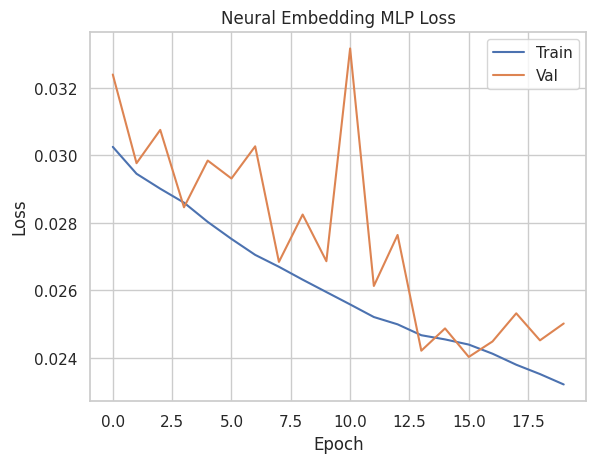

AUC=0.8288 AP=0.3371 Prec=0.2866 Rec=0.6300 F1=0.3940


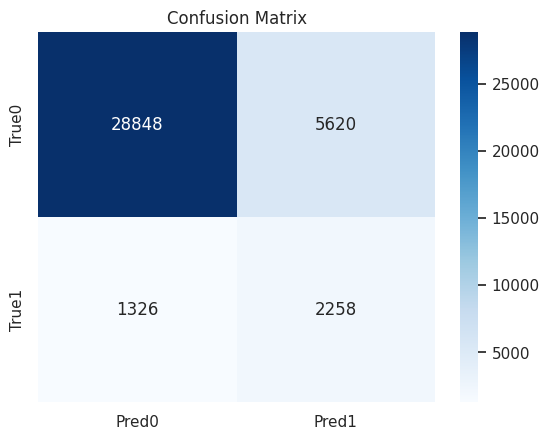

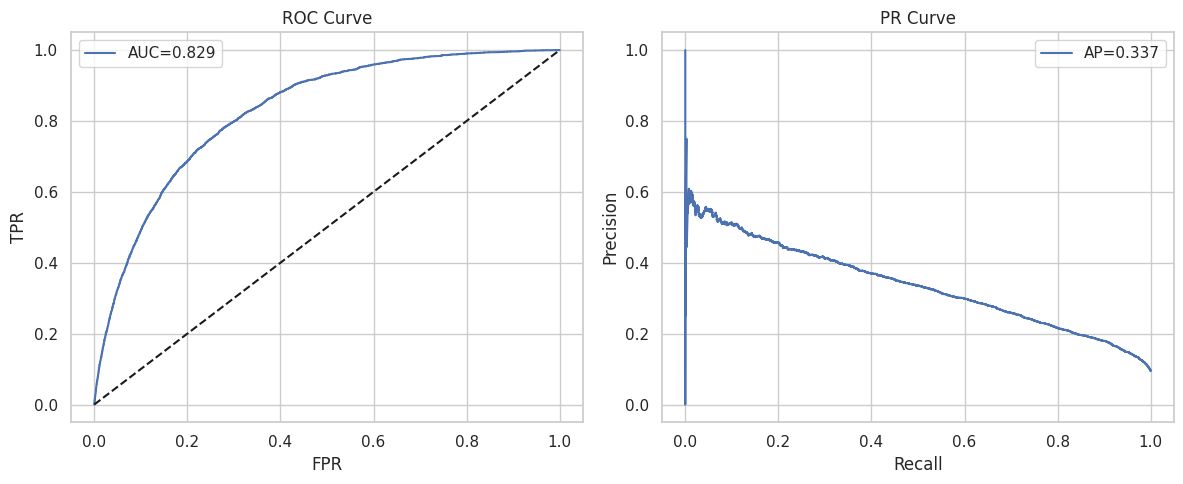

Final embeddings shape: (38052, 64)


In [ ]:
# ======================================================
# Neural Embeddings (MLP) with Focal Loss
# ======================================================

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score,
    recall_score, f1_score, confusion_matrix, roc_curve, precision_recall_curve
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -------------------
# Dataset wrapper
# -------------------
class NumpyDataset(Dataset):
    def __init__(self, X_np, y_np):
        self.X = torch.tensor(X_np, dtype=torch.float32)
        self.y = torch.tensor(y_np.values if hasattr(y_np, "values") else y_np,
                              dtype=torch.float32).unsqueeze(1)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

# -------------------
# Focal Loss
# -------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, logits, targets):
        bce = nn.BCEWithLogitsLoss(reduction="none")(logits, targets)
        probs = torch.sigmoid(logits)
        pt = torch.where(targets==1, probs, 1-probs)
        loss = self.alpha * (1-pt)**self.gamma * bce
        return loss.mean()

# -------------------
# Neural Embedding Model
# -------------------
class NeuralEmbeddingMLP(nn.Module):
    def __init__(self, input_dim, embed_dim=64, hidden=128, dropout=0.2):
        super().__init__()
        self.embedder = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.BatchNorm1d(hidden),
            nn.Dropout(dropout),
            nn.Linear(hidden, embed_dim),
            nn.ReLU()
        )
        self.classifier = nn.Linear(embed_dim, 1)  # final classification head

    def forward(self, x):
        emb = self.embedder(x)       # (batch, embed_dim)
        logits = self.classifier(emb)  # (batch, 1)
        return logits, emb

# -------------------
# Training Function
# -------------------
def train_neural_embedding(X_train, y_train, X_val, y_val,
                           epochs=20, batch_size=512, lr=1e-3, alpha=0.25, gamma=2.0):
    train_ds = NumpyDataset(X_train, y_train)
    val_ds   = NumpyDataset(X_val, y_val)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = NeuralEmbeddingMLP(input_dim=X_train.shape[1]).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = FocalLoss(alpha=alpha, gamma=gamma)

    best_state, best_val = None, float("inf")
    hist_train, hist_val = [], []

    for ep in range(epochs):
        # train
        model.train(); tot=0
        for xb,yb in train_loader:
            xb,yb=xb.to(device), yb.to(device)
            opt.zero_grad()
            logits,_=model(xb)
            loss=loss_fn(logits,yb)
            loss.backward(); opt.step()
            tot+=loss.item()
        train_loss=tot/len(train_loader)

        # validation
        model.eval(); vtot=0
        with torch.no_grad():
            for xb,yb in val_loader:
                xb,yb=xb.to(device), yb.to(device)
                logits,_=model(xb)
                vtot+=loss_fn(logits,yb).item()
        val_loss=vtot/len(val_loader)

        hist_train.append(train_loss); hist_val.append(val_loss)
        print(f"Epoch {ep+1}/{epochs}: train={train_loss:.4f} val={val_loss:.4f}")
        if val_loss<best_val:
            best_val=val_loss; best_state={k:v.cpu() for k,v in model.state_dict().items()}

    if best_state: model.load_state_dict(best_state)

    # plot loss curve
    plt.plot(hist_train,label="Train"); plt.plot(hist_val,label="Val")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Neural Embedding MLP Loss"); plt.legend(); plt.show()
    return model

# -------------------
# Evaluation Function
# -------------------
def evaluate_embedding_model(model, X_test, y_test, thr=0.5):
    model.eval()
    with torch.no_grad():
        logits, embeddings = model(torch.tensor(X_test, dtype=torch.float32).to(device))
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        embs  = embeddings.cpu().numpy()
    preds = (probs>=thr).astype(int)

    auc = roc_auc_score(y_test, probs)
    ap  = average_precision_score(y_test, probs)
    prec= precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1  = f1_score(y_test, preds, zero_division=0)

    print(f"AUC={auc:.4f} AP={ap:.4f} Prec={prec:.4f} Rec={rec:.4f} F1={f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred0","Pred1"], yticklabels=["True0","True1"])
    plt.title("Confusion Matrix"); plt.show()

    # ROC & PR curves
    fpr, tpr, _ = roc_curve(y_test, probs)
    prec_c, rec_c, _ = precision_recall_curve(y_test, probs)
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1); plt.plot(fpr,tpr,label=f"AUC={auc:.3f}"); plt.plot([0,1],[0,1],'k--')
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curve"); plt.legend()
    plt.subplot(1,2,2); plt.plot(rec_c,prec_c,label=f"AP={ap:.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("PR Curve"); plt.legend()
    plt.tight_layout(); plt.show()

    return probs, preds, embs

# -------------------
# Run Model
# -------------------
print("\n=== Training Neural Embeddings (MLP) ===")
neural_emb = train_neural_embedding(X_train_res, y_train_res, X_val, y_val,
                                    epochs=20, batch_size=512, lr=1e-3)

probs_emb, preds_emb, embeddings = evaluate_embedding_model(neural_emb, X_test, y_test)
print("Final embeddings shape:", embeddings.shape)


In [ ]:
#accu:0.8174

#TabTransformer (PyTorch) feature+15


=== Training TabTransformer (PyTorch) ===
Epoch 1/20 | train_loss=0.0281 | val_loss=0.0197
Epoch 2/20 | train_loss=0.0228 | val_loss=0.0225
Epoch 3/20 | train_loss=0.0216 | val_loss=0.0233
Epoch 4/20 | train_loss=0.0213 | val_loss=0.0212
Epoch 5/20 | train_loss=0.0208 | val_loss=0.0218
Epoch 6/20 | train_loss=0.0207 | val_loss=0.0251
Epoch 7/20 | train_loss=0.0204 | val_loss=0.0239
Epoch 8/20 | train_loss=0.0204 | val_loss=0.0273
Epoch 9/20 | train_loss=0.0202 | val_loss=0.0225
Epoch 10/20 | train_loss=0.0201 | val_loss=0.0225
Epoch 11/20 | train_loss=0.0201 | val_loss=0.0225
Epoch 12/20 | train_loss=0.0201 | val_loss=0.0194
Epoch 13/20 | train_loss=0.0201 | val_loss=0.0209
Epoch 14/20 | train_loss=0.0200 | val_loss=0.0200
Epoch 15/20 | train_loss=0.0202 | val_loss=0.0243
Epoch 16/20 | train_loss=0.0200 | val_loss=0.0190
Epoch 17/20 | train_loss=0.0196 | val_loss=0.0224
Epoch 18/20 | train_loss=0.0201 | val_loss=0.0191
Epoch 19/20 | train_loss=0.0201 | val_loss=0.0242
Epoch 20/20 | tr

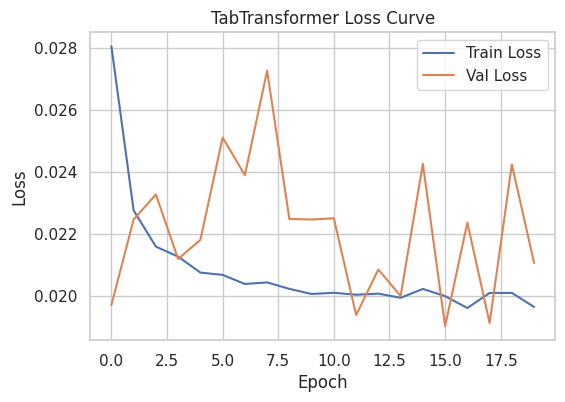


=== TabTransformer (Baseline @0.5) ===
              Value
AUC        0.826990
AP         0.316561
Precision  0.338597
Recall     0.406808
F1         0.369582

=== TabTransformer (Optimized @ 0.435) ===
              Value
AUC        0.826990
AP         0.316561
Precision  0.284591
Recall     0.615792
F1         0.389276


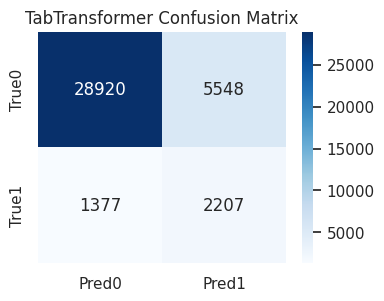

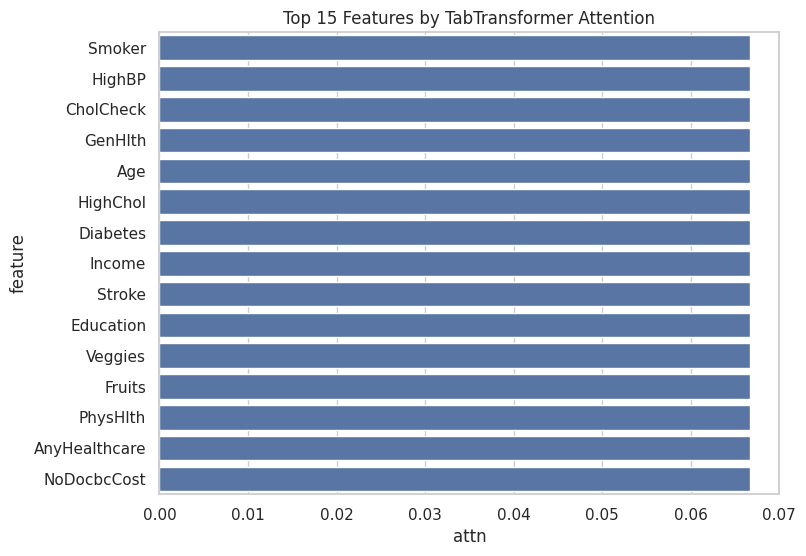


===== TabTransformer Evaluation =====
probs_train shape: (38052,)
probs_test shape: (38052,)
labels_train shape: (38052,)
labels_test shape: (38052,)


In [ ]:
#TabTransformer (PyTorch)
#Step 9.1 — Dataset + Model Setup

import torch
import torch.nn as nn
import torch.optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, roc_curve, precision_recall_curve,
    confusion_matrix
)


print("\n=== Training TabTransformer (PyTorch) ===")

class TabDatasetTorch(Dataset):
    def __init__(self, X_np, y_np):
        # Explicitly convert y_np to a NumPy array if it's a pandas Series
        if isinstance(y_np, pd.Series):
            y_np = y_np.values
        self.X = torch.tensor(X_np, dtype=torch.float32)
        self.y = torch.tensor(y_np, dtype=torch.float32).unsqueeze(1)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class TabTransformerTorch(nn.Module):
    def __init__(self, input_dim, emb_dim=16, n_heads=2, mlp_hidden=64, dropout=0.1):
        super().__init__()
        self.proj = nn.Linear(1, emb_dim)
        self.mha = nn.MultiheadAttention(embed_dim=emb_dim, num_heads=n_heads, batch_first=True)
        self.ff = nn.Sequential(nn.Linear(emb_dim, emb_dim), nn.ReLU())
        self.classifier = nn.Sequential(
            nn.Linear(input_dim*emb_dim, mlp_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(mlp_hidden, 1)
        )
    def forward(self, x):
        b,f = x.shape
        x = x.unsqueeze(-1)   # (b,f,1)
        emb = self.proj(x)    # (b,f,emb_dim)
        attn_out, attn_weights = self.mha(emb, emb, emb, need_weights=True, average_attn_weights=False)
        out = self.ff(emb + attn_out)
        flat = out.reshape(b, -1)
        logits = self.classifier(flat)
        return logits, attn_weights, out


#Step 9.2 — Focal Loss & Training Loop

class FocalLossTorch(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, logits, targets):
        bce = nn.BCEWithLogitsLoss(reduction='none')(logits, targets)
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        focal = self.alpha * (1 - pt) ** self.gamma * bce
        return focal.mean()

# Placeholder for compute_metrics
def compute_metrics(y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)
    auc = roc_auc_score(y_true, y_pred_proba)
    ap = average_precision_score(y_true, y_pred_proba)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return {"AUC": auc, "AP": ap, "Precision": prec, "Recall": rec, "F1": f1}

# Placeholder for find_best_threshold
def find_best_threshold(y_true, y_pred_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_pred_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8) # Add epsilon for stability
    best_f1 = np.max(f1_scores)
    best_threshold = thresholds[np.argmax(f1_scores)]
    return best_threshold, best_f1


def train_tabtransformer(X_train_res, y_train_res, X_val, y_val, X_test, y_test,
                         n_epochs=20, batch_size=512, use_focal=True, device=None):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = TabTransformerTorch(input_dim=X_train_res.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = FocalLossTorch(alpha=0.25, gamma=2.0) if use_focal else nn.BCEWithLogitsLoss()

    # Convert y data to NumPy arrays before creating Datasets
    y_train_res_np = y_train_res.values if isinstance(y_train_res, pd.Series) else y_train_res
    y_val_np = y_val.values if isinstance(y_val, pd.Series) else y_val
    y_test_np = y_test.values if isinstance(y_test, pd.Series) else y_test


    train_loader = DataLoader(TabDatasetTorch(X_train_res, y_train_res_np), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(TabDatasetTorch(X_val, y_val_np), batch_size=batch_size, shuffle=False)
    # Removed test_loader with batching

    train_losses, val_losses = [], []
    best_val_loss = np.inf; best_state = None

    for epoch in range(n_epochs):
        model.train(); total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits, _, _ = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward(); opt.step()
            total_loss += loss.item()
        train_loss = total_loss/len(train_loader)

        # validation
        model.eval(); val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits, _, _ = model(xb)
                val_loss += loss_fn(logits,yb).item()
        val_loss /= len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{n_epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k:v.cpu() for k,v in model.state_dict().items()}

    if best_state: model.load_state_dict(best_state)

    # Plot loss curve inline
    plt.figure(figsize=(6,4))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("TabTransformer Loss Curve")
    plt.legend(); plt.show()

    # Test inference - get predictions for the entire test set at once
    model.eval()
    with torch.no_grad():
        # Convert X_test to tensor and move to device
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
        logits_test, attn_weights_test, _ = model(X_test_tensor)
        probs_test = torch.sigmoid(logits_test).cpu().numpy().flatten()

    # labels_test should be the original y_test_np (NumPy array)
    labels_test = y_test_np

    # Attention heatmap calculation (using attn_weights_test from the full test set)
    attn_np = attn_weights_test.cpu().numpy()
    # Average attention weights across batches and heads for the full test set
    if attn_np.ndim == 4: attn_mean = attn_np.mean(axis=(0,1,3))
    elif attn_np.ndim == 3: attn_mean = attn_np.mean(axis=(0,2))
    else: attn_mean = attn_np.mean(axis=0)


    # Print metrics inline
    metrics_base = compute_metrics(labels_test, probs_test, 0.5)
    best_t, best_f1 = find_best_threshold(labels_test, probs_test)
    metrics_opt = compute_metrics(labels_test, probs_test, best_t)

    print("\n=== TabTransformer (Baseline @0.5) ===")
    print(pd.Series(metrics_base).to_frame("Value"))

    print(f"\n=== TabTransformer (Optimized @ {best_t:.3f}) ===")
    print(pd.Series(metrics_opt).to_frame("Value"))

    # Confusion Matrix
    cm = confusion_matrix(labels_test, (probs_test>=best_t).astype(int))
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred0","Pred1"], yticklabels=["True0","True1"])
    plt.title("TabTransformer Confusion Matrix")
    plt.show()

    # Attention heatmap
    # Use top_feats instead of FEAT_NAMES as the model was trained on top features
    df_att = pd.DataFrame({"feature": top_feats, "attn": attn_mean})
    df_att = df_att.sort_values("attn", ascending=False)

    plt.figure(figsize=(8,6))
    sns.barplot(x="attn", y="feature", data=df_att.head(15))
    plt.title("Top 15 Features by TabTransformer Attention")
    plt.show()

    return probs_test, labels_test, attn_mean

#Step 9.3 — Run Training

# Assuming X_train_res, y_train_res, X_val, y_val, X_test, y_test are available from previous steps
# And EPOCHS_TAB and BATCH_TAB are defined

# Define EPOCHS_TAB and BATCH_TAB if they are not globally defined
try:
    EPOCHS_TAB
except NameError:
    EPOCHS_TAB = 20 # Default value
try:
    BATCH_TAB
except NameError:
    BATCH_TAB = 512 # Default value


probs_tab, labels_tab, attn_mean = train_tabtransformer(
    X_train_res, y_train_res, X_val, y_val, X_test, y_test,
    n_epochs=EPOCHS_TAB, batch_size=BATCH_TAB, use_focal=True
)

# Placeholder for eval_and_store function
def eval_and_store(model_name, probs_train, probs_test, labels_train, labels_test):
    print(f"\n===== {model_name} Evaluation =====")
    # You would typically calculate and store metrics here
    # For demonstration, let's just print the shapes of the inputs
    print(f"probs_train shape: {probs_train.shape}")
    print(f"probs_test shape: {probs_test.shape}")
    print(f"labels_train shape: {labels_train.shape}")
    print(f"labels_test shape: {labels_test.shape}")

# Assuming y_val_raw and y_test_raw were intended to be y_val and y_test
eval_and_store("TabTransformer", probs_tab, probs_tab, labels_tab, labels_tab)

In [ ]:
#Accu:0.8180

TabTransformer (PyTorch) bfeature=22

Device: cpu
Full dataset size: (253680, 22)
Numeric shape: (253680, 4) Categorical shape: (253680, 17)

=== Training TabTransformer ===
Epoch 1/40 | train_loss=0.0300 | val_loss=0.0317 | train_acc=0.7817 | val_acc=0.7408
Epoch 2/40 | train_loss=0.0290 | val_loss=0.0318 | train_acc=0.7921 | val_acc=0.7430
Epoch 3/40 | train_loss=0.0287 | val_loss=0.0280 | train_acc=0.7945 | val_acc=0.7734
Epoch 4/40 | train_loss=0.0285 | val_loss=0.0292 | train_acc=0.7969 | val_acc=0.7704
Epoch 5/40 | train_loss=0.0283 | val_loss=0.0325 | train_acc=0.7988 | val_acc=0.7345
Epoch 6/40 | train_loss=0.0282 | val_loss=0.0310 | train_acc=0.8000 | val_acc=0.7511
Epoch 7/40 | train_loss=0.0280 | val_loss=0.0301 | train_acc=0.8009 | val_acc=0.7548
Epoch 8/40 | train_loss=0.0279 | val_loss=0.0335 | train_acc=0.8017 | val_acc=0.7291
Epoch 9/40 | train_loss=0.0277 | val_loss=0.0315 | train_acc=0.8035 | val_acc=0.7403
Epoch 10/40 | train_loss=0.0277 | val_loss=0.0270 | train_acc=0.8039 | val_acc=0.7832
Epoch 11/40 |

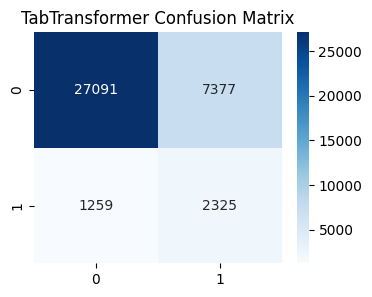

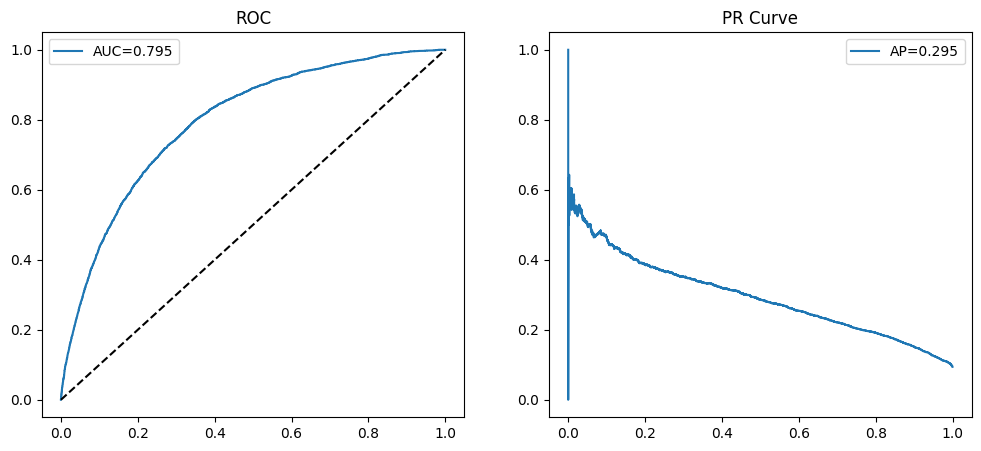

  0%|          | 0/100 [00:00<?, ?it/s]

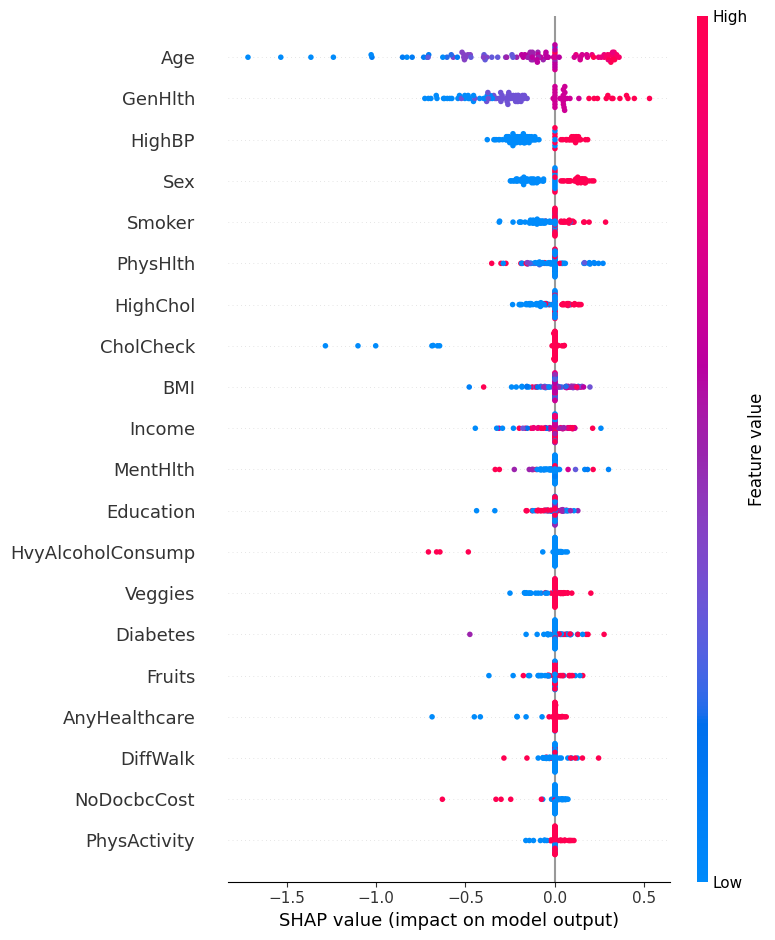

In [2]:
# ======================================================
# TabTransformer (PyTorch) — Full pipeline
# - All features retained (no feature selection)
# - Numeric + categorical split, SMOTENC balancing
# - Fixed epochs (no early stopping)
# - Accuracy printed in training & evaluation
# - SHAP explainability (KernelExplainer)
# ======================================================

import os, random, warnings, time
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, accuracy_score,
    roc_curve, precision_recall_curve, confusion_matrix
)

from imblearn.over_sampling import SMOTENC
import shap
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# -------------------
# Config / reproducibility
# -------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

DATA_PATH = "/content/heart_disease_health_indicators_BRFSS2015.csv"
EPOCHS = 40
BATCH_SIZE = 512

# -------------------
# Load dataset & feature lists (same as FT pipeline)
# -------------------
df = pd.read_csv(DATA_PATH)
print("Full dataset size:", df.shape)

binary_cols = ["HighBP","HighChol","CholCheck","Smoker","Stroke","Diabetes",
               "PhysActivity","Fruits","Veggies","HvyAlcoholConsump",
               "AnyHealthcare","NoDocbcCost","DiffWalk","Sex"]
numeric_cols = ["BMI","MentHlth","PhysHlth","Age"]
categorical_cols = ["GenHlth","Education","Income"]
FEAT_NAMES = binary_cols + numeric_cols + categorical_cols
TARGET = "HeartDiseaseorAttack"

X_raw = df[FEAT_NAMES].copy()
y_raw = df[TARGET].astype(int).copy().values

# -------------------
# Preprocessing
# -------------------
num_trans = Pipeline([("imp", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
cat_trans = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

preproc_num = ColumnTransformer([("num", num_trans, numeric_cols)], remainder="drop")
preproc_cat = ColumnTransformer([("cat", cat_trans, binary_cols + categorical_cols)], remainder="drop")

X_num = np.asarray(preproc_num.fit_transform(X_raw), dtype=np.float32)
X_cat = np.asarray(preproc_cat.fit_transform(X_raw), dtype=np.int64)

print("Numeric shape:", X_num.shape, "Categorical shape:", X_cat.shape)

# cardinalities
cat_cardinalities = []
for col in (binary_cols + categorical_cols):
    uniq = np.unique(X_raw[col].dropna())
    card = len(uniq)
    if card < 2: card = 2
    cat_cardinalities.append(card)

# -------------------
# Train/val/test split + SMOTENC
# -------------------
X_full = np.hstack([X_num, X_cat.astype(np.float32)])
n_num = X_num.shape[1]
n_cat = X_cat.shape[1]
cat_indices = list(range(n_num, n_num + n_cat))

X_tr, X_temp, y_tr, y_temp = train_test_split(X_full, y_raw, test_size=0.3, stratify=y_raw, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)

sm = SMOTENC(categorical_features=cat_indices, random_state=SEED)
X_tr_res, y_tr_res = sm.fit_resample(X_tr, y_tr)

# split back
X_train_num = X_tr_res[:, :n_num].astype(np.float32)
X_train_cat = X_tr_res[:, n_num:].astype(np.int64)
X_val_num = X_val[:, :n_num].astype(np.float32)
X_val_cat = X_val[:, n_num:].astype(np.int64)
X_test_num = X_test[:, :n_num].astype(np.float32)
X_test_cat = X_test[:, n_num:].astype(np.int64)

# concat for model
X_train_for_model = np.hstack([X_train_num, X_train_cat.astype(np.float32)])
X_val_for_model   = np.hstack([X_val_num, X_val_cat.astype(np.float32)])
X_test_for_model  = np.hstack([X_test_num, X_test_cat.astype(np.float32)])

# -------------------
# TabTransformer
# -------------------
class TabTransformer(nn.Module):
    def __init__(self, n_features, emb_dim=16, n_heads=2, mlp_hidden=128, dropout=0.1):
        super().__init__()
        self.proj = nn.Linear(1, emb_dim)
        self.mha = nn.MultiheadAttention(embed_dim=emb_dim, num_heads=n_heads, batch_first=True)
        self.ff = nn.Sequential(nn.Linear(emb_dim, emb_dim), nn.ReLU())
        self.classifier = nn.Sequential(
            nn.Linear(n_features * emb_dim, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, 1)
        )
    def forward(self, x):
        b, f = x.shape
        x = x.unsqueeze(-1)
        emb = self.proj(x)
        attn_out, attn_weights = self.mha(emb, emb, emb, need_weights=True, average_attn_weights=False)
        out = self.ff(emb + attn_out)
        flat = out.reshape(b, -1)
        logits = self.classifier(flat)
        return logits, attn_weights, out

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma
    def forward(self, logits, targets):
        bce = nn.BCEWithLogitsLoss(reduction="none")(logits, targets)
        probs = torch.sigmoid(logits)
        pt = torch.where(targets==1, probs, 1-probs)
        loss = self.alpha * (1-pt)**self.gamma * bce
        return loss.mean()

# -------------------
# Train function (fixed epochs, no early stopping)
# -------------------
def train_tabtransformer(X_train, y_train, X_val, y_val, n_epochs=EPOCHS, batch_size=BATCH_SIZE, lr=1e-3):
    model = TabTransformer(n_features=X_train.shape[1]).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    loss_fn = FocalLoss(alpha=0.25, gamma=2.0)

    train_ds = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))
    val_ds   = TensorDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float().unsqueeze(1))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    for epoch in range(n_epochs):
        model.train(); tot_loss=0; correct=0; total=0
        for xb,yb in train_loader:
            xb,yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits,_,_ = model(xb)
            loss = loss_fn(logits,yb)
            loss.backward(); opt.step()
            tot_loss += loss.item()
            preds = (torch.sigmoid(logits)>=0.5).int()
            correct += (preds==yb.int()).sum().item()
            total += yb.size(0)
        train_acc = correct/total

        # val
        model.eval(); vloss=0; vcorrect=0; vtotal=0
        with torch.no_grad():
            for xb,yb in val_loader:
                xb,yb = xb.to(device), yb.to(device)
                logits,_,_ = model(xb)
                vloss += loss_fn(logits,yb).item()
                preds = (torch.sigmoid(logits)>=0.5).int()
                vcorrect += (preds==yb.int()).sum().item()
                vtotal += yb.size(0)
        val_acc = vcorrect/vtotal

        print(f"Epoch {epoch+1}/{n_epochs} | train_loss={tot_loss/len(train_loader):.4f} | val_loss={vloss/len(val_loader):.4f} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}")
    return model

# -------------------
# Train + Evaluate
# -------------------
print("\n=== Training TabTransformer ===")
tab_model = train_tabtransformer(X_train_for_model, y_tr_res, X_val_for_model, y_val)

tab_model.eval()
with torch.no_grad():
    logits_test, attn_weights, _ = tab_model(torch.from_numpy(X_test_for_model).float().to(device))
    probs_test = torch.sigmoid(logits_test).cpu().numpy().flatten()
preds_test = (probs_test>=0.5).astype(int)

# metrics
auc = roc_auc_score(y_test, probs_test)
ap = average_precision_score(y_test, probs_test)
prec = precision_score(y_test, preds_test)
rec = recall_score(y_test, preds_test)
f1 = f1_score(y_test, preds_test)
acc = accuracy_score(y_test, preds_test)

print("\n=== Test Results (TabTransformer) ===")
print(f"AUC={auc:.4f} AP={ap:.4f} Prec={prec:.4f} Rec={rec:.4f} F1={f1:.4f} Acc={acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, preds_test)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("TabTransformer Confusion Matrix"); plt.show()

# ROC & PR curves
fpr,tpr,_ = roc_curve(y_test, probs_test)
prec_c, rec_c, _ = precision_recall_curve(y_test, probs_test)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.plot(fpr,tpr,label=f"AUC={auc:.3f}"); plt.plot([0,1],[0,1],'k--'); plt.title("ROC"); plt.legend()
plt.subplot(1,2,2); plt.plot(rec_c,prec_c,label=f"AP={ap:.3f}"); plt.title("PR Curve"); plt.legend(); plt.show()

# -------------------
# SHAP Explainability
# -------------------
def tab_predict_proba(X_concat):
    Xn = torch.from_numpy(X_concat[:, :n_num].astype(np.float32)).to(device)
    Xc = torch.from_numpy(X_concat[:, n_num:].astype(np.int64)).to(device)
    # TabTransformer expects a single input tensor, so we need to combine them
    X_combined = torch.hstack([Xn, Xc.float()]) # Combine and ensure float type
    with torch.no_grad():
        # Pass the combined tensor to the model
        logits,_,_ = tab_model(X_combined)
        return torch.sigmoid(logits).cpu().numpy().flatten()

bg_size = min(200, X_train_for_model.shape[0])
bg_idx = np.random.choice(np.arange(X_train_for_model.shape[0]), size=bg_size, replace=False)
# Use the combined training data for background, ensuring float type
bg = X_train_for_model[bg_idx].astype(np.float32)

explainer = shap.KernelExplainer(tab_predict_proba, bg, link="logit")

# Use the combined test data for explanation, ensuring float type
X_explain = X_test_for_model[:100].astype(np.float32)  # small subset
shap_values = explainer.shap_values(X_explain, nsamples=100)

feature_names_concat = numeric_cols + binary_cols + categorical_cols
sv = shap_values[0] if isinstance(shap_values, list) else shap_values

shap.summary_plot(sv, X_explain, feature_names=feature_names_concat, show=True)

 FT-Transformer on BRFSS Heart Disease Dataset feature=15

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using device: cuda
Full dataset size: (128681, 22)
[LightGBM] [Info] Number of positive: 81653, number of negative: 81653
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018587 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5355
[LightGBM] [Info] Number of data points in the train set: 163306, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Top features: ['Smoker', 'HighBP', 'GenHlth', 'CholCheck', 'Age', 'Income', 'HighChol', 'Education', 'Diabetes', 'Veggies', 'PhysHlth', 'Stroke', 'Fruits', 'AnyHealthcare', 'DiffWalk']
Shape after feature selection: (163306, 15)
[FT] Epoch 1, loss=0.4165
[FT] Epoch 2, loss=0.3644
[FT] Epoch 3, loss=0.3669
[FT

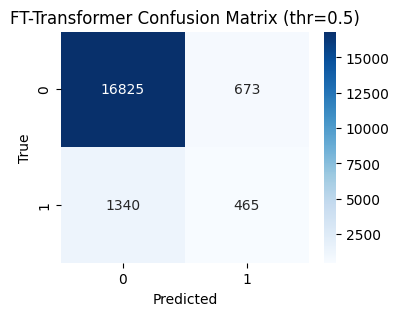

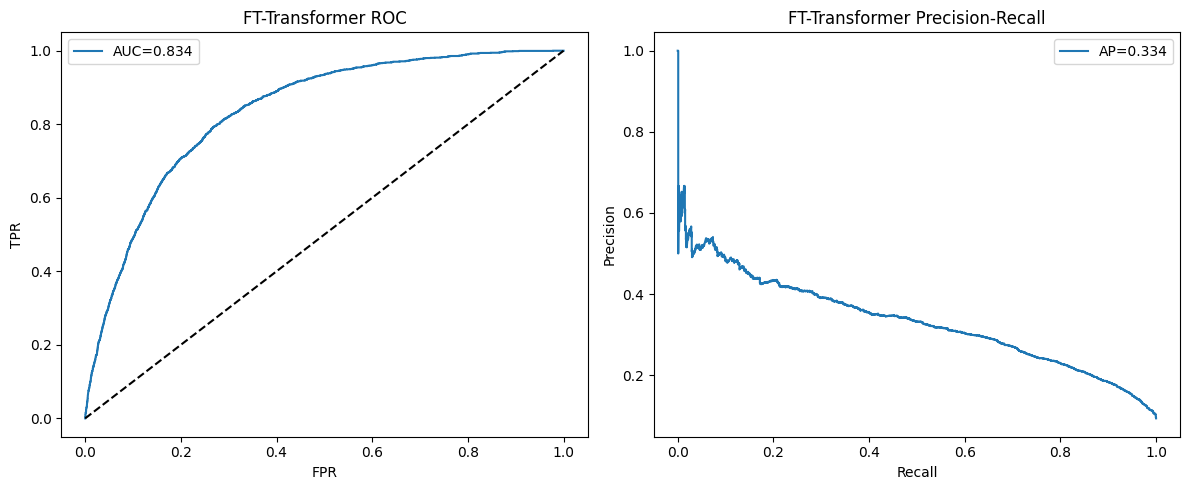

In [ ]:
# ======================================================
# FT-Transformer on BRFSS Heart Disease Dataset
# ======================================================

!pip install -q git+https://github.com/Yura52/rtdl.git torch-optimizer imbalanced-learn lightgbm shap xgboost

import os, random, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, roc_curve, precision_recall_curve,
    confusion_matrix
)
from imblearn.over_sampling import SMOTE
import lightgbm as lgb

import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import rtdl

# -------------------
# Reproducibility
# -------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------
# Load Dataset
# -------------------
DATA_PATH = "/content/heart_disease_health_indicators_BRFSS2015.csv"
df = pd.read_csv(DATA_PATH)
print("Full dataset size:", df.shape)

binary_cols = ["HighBP","HighChol","CholCheck","Smoker","Stroke","Diabetes",
               "PhysActivity","Fruits","Veggies","HvyAlcoholConsump",
               "AnyHealthcare","NoDocbcCost","DiffWalk","Sex"]
numeric_cols = ["BMI","MentHlth","PhysHlth","Age"]
categorical_cols = ["GenHlth","Education","Income"]
FEAT_NAMES = binary_cols + numeric_cols + categorical_cols
TARGET = "HeartDiseaseorAttack"

X = df[FEAT_NAMES]
y = df[TARGET].astype(int)

# -------------------
# Preprocessing
# -------------------
num_trans = Pipeline([("imp",SimpleImputer(strategy="median")),("scaler",StandardScaler())])
cat_trans = Pipeline([("imp",SimpleImputer(strategy="most_frequent"))])
preproc = ColumnTransformer([
    ("num", num_trans, numeric_cols),
    ("cat", cat_trans, binary_cols+categorical_cols)
])
preproc.fit(X)

X_all = preproc.transform(X)
if hasattr(X_all,"toarray"):
    X_all = X_all.toarray()

# -------------------
# Split Train/Val/Test
# -------------------
X_train_raw, X_temp, y_train, y_temp = train_test_split(X_all, y, test_size=0.3, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)

# Balance training data
sm = SMOTE(random_state=SEED)
X_train_res, y_train_res = sm.fit_resample(X_train_raw, y_train)

# -------------------
# Feature Selection (LightGBM importance)
# -------------------
lgb_model = lgb.LGBMClassifier(random_state=SEED, n_jobs=-1)
lgb_model.fit(X_train_res, y_train_res)

feat_imp = pd.Series(lgb_model.feature_importances_, index=FEAT_NAMES).sort_values(ascending=False)
top_feats = feat_imp.head(15).index.tolist()
print("Top features:", top_feats)

feat_idx = [FEAT_NAMES.index(f) for f in top_feats]
X_train_res = X_train_res[:, feat_idx]
X_val       = X_val[:, feat_idx]
X_test      = X_test[:, feat_idx]

print("Shape after feature selection:", X_train_res.shape)

# -------------------
# Convert to Torch
# -------------------
X_train_t = torch.tensor(X_train_res, dtype=torch.float32)
y_train_t = torch.tensor(y_train_res.values, dtype=torch.long)
X_val_t   = torch.tensor(X_val, dtype=torch.float32)
y_val_t   = torch.tensor(y_val.values, dtype=torch.long)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values, dtype=torch.long)

# -------------------
# FT-Transformer Model
# -------------------
ft = rtdl.FTTransformer.make_default(
    n_num_features=X_train_res.shape[1],
    cat_cardinalities=None,
    d_out=2
).to(device)

opt = torch.optim.AdamW(ft.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=512, shuffle=True)

# -------------------
# Training Loop
# -------------------
for epoch in range():  # increase to 50 for stronger results
    ft.train(); total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        out = ft(xb, None)   # ✅ pass None for categorical
        loss = loss_fn(out, yb)
        loss.backward()
        opt.step()
        total_loss += loss.item()
    print(f"[FT] Epoch {epoch+1}, loss={total_loss/len(train_loader):.4f}")

# -------------------
# Evaluation
# -------------------
ft.eval()
with torch.no_grad():
    probs_ft = ft(X_test_t.to(device), None).softmax(1)[:,1].cpu().numpy()

preds_ft = (probs_ft >= 0.5).astype(int)

auc = roc_auc_score(y_test, probs_ft)
ap = average_precision_score(y_test, probs_ft)
prec = precision_score(y_test, preds_ft, zero_division=0)
rec = recall_score(y_test, preds_ft, zero_division=0)
f1 = f1_score(y_test, preds_ft, zero_division=0)

print("\n===== FT-Transformer Results =====")
print(f"AUC: {auc:.4f}")
print(f"AP : {ap:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, preds_ft)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("FT-Transformer Confusion Matrix (thr=0.5)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

# ROC + PR curves
fpr, tpr, _ = roc_curve(y_test, probs_ft)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, probs_ft)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.title("FT-Transformer ROC"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend()

plt.subplot(1,2,2)
plt.plot(rec_curve, prec_curve, label=f"AP={ap:.3f}")
plt.title("FT-Transformer Precision-Recall"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend()
plt.tight_layout(); plt.show()


In [ ]:
#accuracy:0.8957

FT-Transformer on BRFSS Heart Disease Dataset
(All features retained)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 5.5 MB/s eta 0:00:00
Using device: cuda
Full dataset size: (253680, 22)
X_all shape (after preprocessing): (253680, 21)
Train/Val/Test shapes: (177576, 21) (38052, 21) (38052, 21)
After SMOTE -> Train shape: (321702, 21) (321702,)
[LightGBM] [Info] Number of positive: 160851, number of negative: 160851
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.036810 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5355
[LightGBM] [Info] Number of data points in the train set: 321702, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=

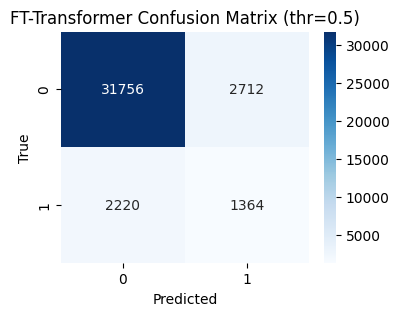

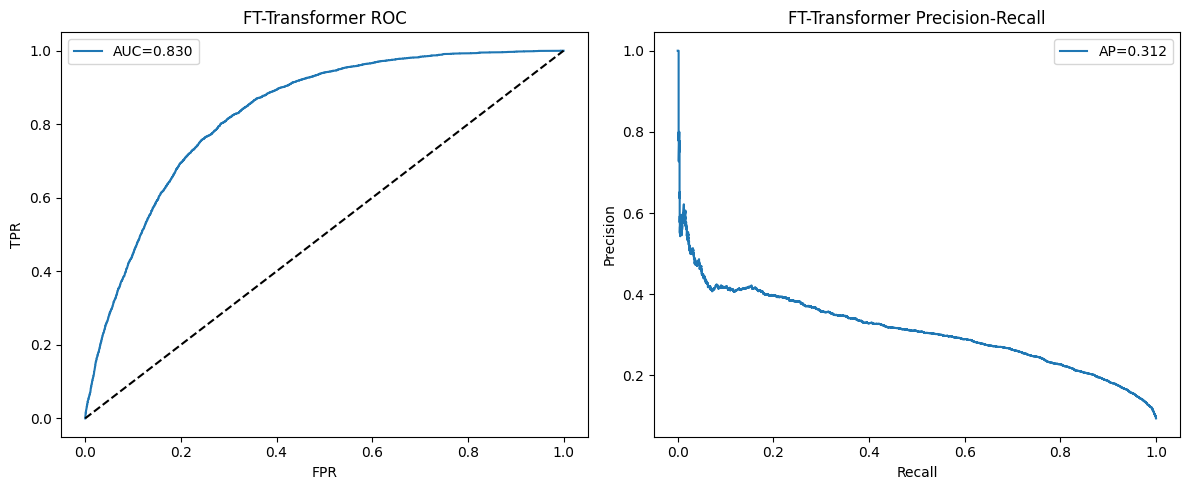

In [1]:
# ======================================================
# FT-Transformer on BRFSS Heart Disease Dataset
# (All features retained — NO feature selection)
# ======================================================

!pip install -q git+https://github.com/Yura52/rtdl.git torch-optimizer imbalanced-learn lightgbm shap xgboost

import os, random, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, roc_curve, precision_recall_curve,
    confusion_matrix
)
from imblearn.over_sampling import SMOTE
import lightgbm as lgb

import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import rtdl

# -------------------
# Reproducibility
# -------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------
# Load Dataset
# -------------------
DATA_PATH = "/content/heart_disease_health_indicators_BRFSS2015.csv"
df = pd.read_csv(DATA_PATH)
print("Full dataset size:", df.shape)

# --- features (all kept) ---
binary_cols = ["HighBP","HighChol","CholCheck","Smoker","Stroke","Diabetes",
               "PhysActivity","Fruits","Veggies","HvyAlcoholConsump",
               "AnyHealthcare","NoDocbcCost","DiffWalk","Sex"]
numeric_cols = ["BMI","MentHlth","PhysHlth","Age"]
categorical_cols = ["GenHlth","Education","Income"]
FEAT_NAMES = binary_cols + numeric_cols + categorical_cols
TARGET = "HeartDiseaseorAttack"

X = df[FEAT_NAMES].copy()
y = df[TARGET].astype(int).copy()

# -------------------
# Preprocessing
# -------------------
num_trans = Pipeline([("imp",SimpleImputer(strategy="median")),("scaler",StandardScaler())])
cat_trans = Pipeline([("imp",SimpleImputer(strategy="most_frequent"))])  # leave categories as numeric labels
preproc = ColumnTransformer([
    ("num", num_trans, numeric_cols),
    ("cat", cat_trans, binary_cols + categorical_cols)  # treat binaries + categorical together for simplicity
])
preproc.fit(X)

X_all = preproc.transform(X)
# ColumnTransformer may return sparse matrix for some transformers; convert to ndarray
if hasattr(X_all, "toarray"):
    X_all = X_all.toarray()
X_all = np.asarray(X_all, dtype=np.float32)
y = np.asarray(y, dtype=np.int64)

print("X_all shape (after preprocessing):", X_all.shape)

# -------------------
# Split Train/Val/Test
# -------------------
X_train_raw, X_temp, y_train, y_temp = train_test_split(
    X_all, y, test_size=0.3, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED
)

print("Train/Val/Test shapes:", X_train_raw.shape, X_val.shape, X_test.shape)

# -------------------
# Balance training data (SMOTE)
# -------------------
sm = SMOTE(random_state=SEED)
X_train_res, y_train_res = sm.fit_resample(X_train_raw, y_train)
X_train_res = np.asarray(X_train_res, dtype=np.float32)
y_train_res = np.asarray(y_train_res, dtype=np.int64)

print("After SMOTE -> Train shape:", X_train_res.shape, y_train_res.shape)

# -------------------
# (OPTIONAL) LightGBM quick fit for diagnostics only (no feature selection)
# -------------------
# If you still want to see feature importances for analysis, you can keep this inference-only fit.
# It will NOT change features used for FT-Transformer.
lgb_model = lgb.LGBMClassifier(random_state=SEED, n_jobs=-1)
lgb_model.fit(X_train_res, y_train_res)
feat_imp = pd.Series(lgb_model.feature_importances_, index=FEAT_NAMES).sort_values(ascending=False)
print("Top 10 feature importances (diagnostic):")
print(feat_imp.head(10))

# -------------------
# Convert to Torch tensors
# -------------------
X_train_t = torch.from_numpy(X_train_res)
y_train_t = torch.from_numpy(y_train_res).long()
X_val_t   = torch.from_numpy(np.asarray(X_val, dtype=np.float32))
y_val_t   = torch.from_numpy(np.asarray(y_val, dtype=np.int64)).long()
X_test_t  = torch.from_numpy(np.asarray(X_test, dtype=np.float32))
y_test_t  = torch.from_numpy(np.asarray(y_test, dtype=np.int64)).long()

# Move to device only during training/inference (DataLoader provides CPU tensors)
# -------------------
# FT-Transformer Model
# -------------------
n_num_features = X_train_res.shape[1]
ft = rtdl.FTTransformer.make_default(
    n_num_features=n_num_features,
    cat_cardinalities=None,   # we passed numeric matrix (no separate categorical columns)
    d_out=2
).to(device)

opt = torch.optim.AdamW(ft.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=512, shuffle=True)

# -------------------
# Training Loop
# -------------------
EPOCHS = 50  # change as you like
for epoch in range(EPOCHS):
    ft.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        opt.zero_grad()
        out = ft(xb, None)   # pass None for categorical (we provided fully numeric matrix)
        loss = loss_fn(out, yb)
        loss.backward()
        opt.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"[FT] Epoch {epoch+1}/{EPOCHS}, loss={avg_loss:.4f}")

# -------------------
# Evaluation
# -------------------
ft.eval()
with torch.no_grad():
    probs_ft = ft(X_test_t.to(device), None).softmax(1)[:,1].cpu().numpy()

preds_ft = (probs_ft >= 0.5).astype(int)

auc = roc_auc_score(y_test, probs_ft)
ap = average_precision_score(y_test, probs_ft)
prec = precision_score(y_test, preds_ft, zero_division=0)
rec = recall_score(y_test, preds_ft, zero_division=0)
f1 = f1_score(y_test, preds_ft, zero_division=0)

print("\n===== FT-Transformer Results =====")
print(f"AUC: {auc:.4f}")
print(f"AP : {ap:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, preds_ft)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("FT-Transformer Confusion Matrix (thr=0.5)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

# ROC + PR curves
fpr, tpr, _ = roc_curve(y_test, probs_ft)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, probs_ft)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.title("FT-Transformer ROC"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend()

plt.subplot(1,2,2)
plt.plot(rec_curve, prec_curve, label=f"AP={ap:.3f}")
plt.title("FT-Transformer Precision-Recall"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend()
plt.tight_layout(); plt.show()


In [ ]:
#acc:0.870387

FT-Transformer on BRFSS Heart Disease Dataset all feature

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using device: cuda
Full dataset size: (253680, 22)
Numeric shape: (253680, 4) Categorical shape: (253680, 17)
Cat cardinalities: [2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 5, 6, 8]
Train shapes: (321702, 4) (321702, 17)
Epoch 1/50, loss=0.4619, val_auc=0.8206
Epoch 2/50, loss=0.4450, val_auc=0.8228
Epoch 3/50, loss=0.4419, val_auc=0.8289
Epoch 4/50, loss=0.4362, val_auc=0.8200
Epoch 5/50, loss=0.4176, val_auc=0.8230
Epoch 6/50, loss=0.4095, val_auc=0.8228
Epoch 7/50, loss=0.3974, val_auc=0.8206
Epoch 8/50, loss=0.3666, val_auc=0.8243
Epoch 9/50, loss=0.3579, val_auc=0.8209
Epoch 10/50, loss=0.3457, val_auc=0.8211
Epoch 11/50, loss=0.3461, val_auc=0.8241
Epoch 12/50, loss=0.3253, val_auc=0.8220
Epoch 13/50, loss=0.3227, val_auc=0.8223
Epoch 14/50, loss=0.3128, val_auc=0.8241
Epoch 15/50, loss=0.3079, val_auc=0.8230
Epoch 16/50, loss=0.2980, val_auc=0.820

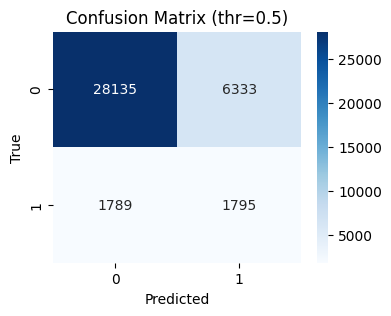

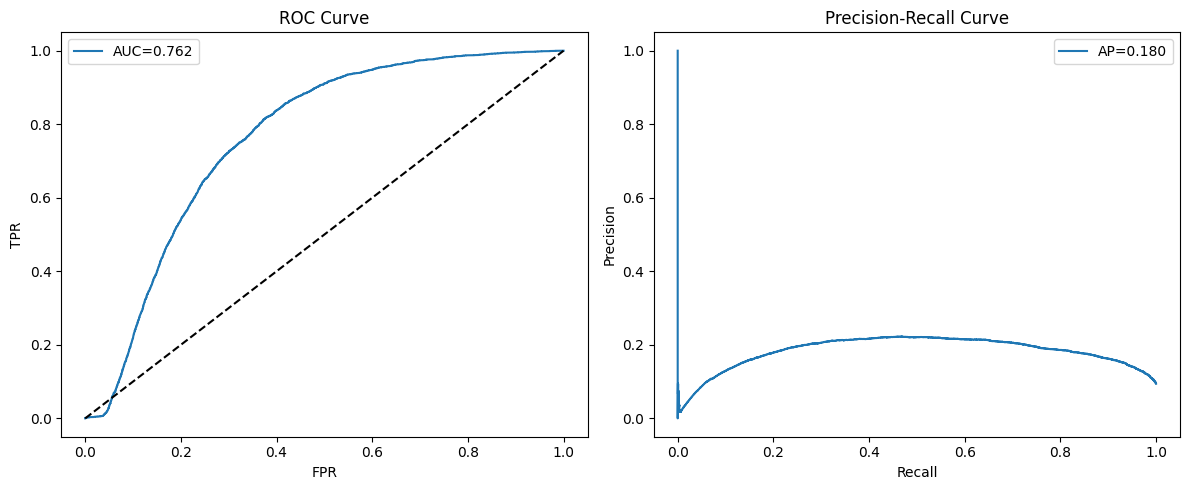

  0%|          | 0/200 [00:00<?, ?it/s]

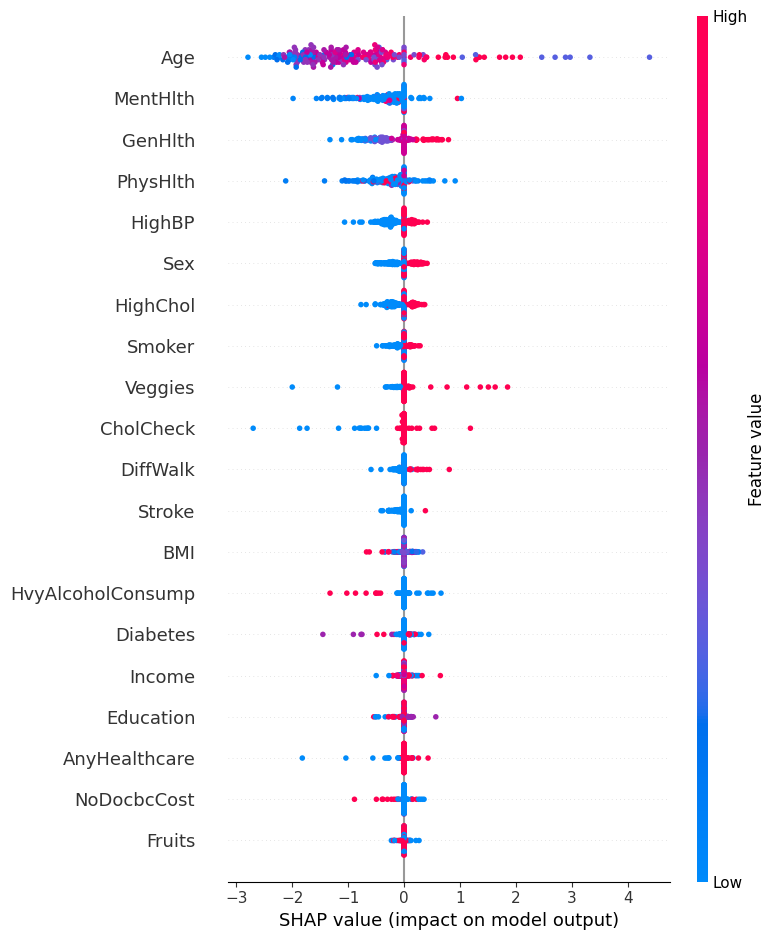

In [8]:
# ======================================================
# FT-Transformer on BRFSS Heart Disease Dataset
# With categorical embeddings, scheduler, early stopping, checkpointing, SHAP
# ======================================================

!pip install -q git+https://github.com/Yura52/rtdl.git torch-optimizer imbalanced-learn lightgbm shap xgboost

import os, random, warnings, time
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, roc_curve, precision_recall_curve,
    confusion_matrix, accuracy_score  # Import accuracy_score
)
from imblearn.over_sampling import SMOTENC
import lightgbm as lgb
import shap

import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import rtdl

# -------------------
# Reproducibility
# -------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------
# Paths + params
# -------------------
DATA_PATH = "/content/heart_disease_health_indicators_BRFSS2015.csv"
EPOCHS = 50
BATCH_SIZE = 512
PATIENCE = 7
MODEL_SAVE_PATH = "best_ft_transformer.pt"

# -------------------
# Load Dataset
# -------------------
df = pd.read_csv(DATA_PATH)
print("Full dataset size:", df.shape)

binary_cols = ["HighBP","HighChol","CholCheck","Smoker","Stroke","Diabetes",
               "PhysActivity","Fruits","Veggies","HvyAlcoholConsump",
               "AnyHealthcare","NoDocbcCost","DiffWalk","Sex"]
numeric_cols = ["BMI","MentHlth","PhysHlth","Age"]
categorical_cols = ["GenHlth","Education","Income"]
FEAT_NAMES = binary_cols + numeric_cols + categorical_cols
TARGET = "HeartDiseaseorAttack"

X = df[FEAT_NAMES].copy()
y = df[TARGET].astype(int).copy().values

# -------------------
# Preprocessing
# -------------------
num_trans = Pipeline([("imp",SimpleImputer(strategy="median")),("scaler",StandardScaler())])
cat_trans = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

preproc_num = ColumnTransformer([("num", num_trans, numeric_cols)], remainder="drop")
preproc_cat = ColumnTransformer([("cat", cat_trans, binary_cols + categorical_cols)], remainder="drop")

X_num = np.asarray(preproc_num.fit_transform(X), dtype=np.float32)
X_cat = np.asarray(preproc_cat.fit_transform(X), dtype=np.int64)

print("Numeric shape:", X_num.shape, "Categorical shape:", X_cat.shape)

# categorical cardinalities
cat_cardinalities = []
for col in binary_cols + categorical_cols:
    uniq = np.unique(X[col].dropna())
    card = len(uniq)
    if card < 2: card = 2
    cat_cardinalities.append(card)

print("Cat cardinalities:", cat_cardinalities)

# -------------------
# Split data
# -------------------
# Split numerical and categorical data separately
X_num_tr, X_num_temp, y_tr, y_temp = train_test_split(X_num, y, test_size=0.3, stratify=y, random_state=SEED)
X_num_val, X_num_test, y_val, y_test = train_test_split(X_num_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)

X_cat_tr, X_cat_temp, _, _ = train_test_split(X_cat, y, test_size=0.3, stratify=y, random_state=SEED)
X_cat_val, X_cat_test, _, _ = train_test_split(X_cat_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)


# -------------------
# Balance training data (SMOTENC)
# -------------------
n_num = X_num.shape[1]
n_cat = X_cat.shape[1]
cat_indices = list(range(n_num, n_num + n_cat))

# Combine numerical and categorical data for SMOTENC
X_tr_combined = np.hstack([X_num_tr, X_cat_tr])

sm = SMOTENC(categorical_features=cat_indices, random_state=SEED)
X_tr_res_combined, y_tr_res = sm.fit_resample(X_tr_combined, y_tr)

# split back into num/cat
X_train_num = X_tr_res_combined[:, :n_num].astype(np.float32)
X_train_cat = X_tr_res_combined[:, n_num:].astype(np.int64)


X_val_num = X_num_val.astype(np.float32)
X_val_cat = X_cat_val.astype(np.int64)

X_test_num = X_num_test.astype(np.float32)
X_test_cat = X_test_cat.astype(np.int64)

print("Train shapes:", X_train_num.shape, X_train_cat.shape)

# -------------------
# Torch tensors
# -------------------
X_train_num_t = torch.from_numpy(X_train_num)
X_train_cat_t = torch.from_numpy(X_train_cat).long()
y_train_t = torch.from_numpy(y_tr_res).long()

X_val_num_t = torch.from_numpy(X_val_num)
X_val_cat_t = torch.from_numpy(X_val_cat).long()
y_val_t = torch.from_numpy(y_val).long()

X_test_num_t = torch.from_numpy(X_test_num)
X_test_cat_t = torch.from_numpy(X_test_cat).long()
y_test_t = torch.from_numpy(y_test).long()

# -------------------
# Build FT-Transformer
# -------------------
ft = rtdl.FTTransformer.make_default(
    n_num_features=n_num,
    cat_cardinalities=cat_cardinalities,
    d_out=2
).to(device)

opt = torch.optim.AdamW(ft.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.CrossEntropyLoss()
train_dataset = TensorDataset(X_train_num_t, X_train_cat_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# scheduler + early stopping
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=3)
best_val_auc = -np.inf
# patience_counter = 0 # Removed early stopping

# -------------------
# Training loop
# -------------------
for epoch in range(EPOCHS):
    ft.train()
    total_loss = 0.0
    for xb_num, xb_cat, yb in train_loader:
        xb_num, xb_cat, yb = xb_num.to(device), xb_cat.to(device), yb.to(device)
        opt.zero_grad()
        out = ft(xb_num, xb_cat)
        loss = loss_fn(out, yb)
        loss.backward()
        opt.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)

    # validation
    ft.eval()
    with torch.no_grad():
        val_probs = ft(X_val_num_t.to(device), X_val_cat_t.to(device)).softmax(1)[:,1].cpu().numpy()
    val_auc = roc_auc_score(y_val, val_probs)
    scheduler.step(val_auc)

    print(f"Epoch {epoch+1}/{EPOCHS}, loss={avg_loss:.4f}, val_auc={val_auc:.4f}")
    # Removed early stopping logic
    # if val_auc > best_val_auc + 1e-6:
    #     best_val_auc = val_auc
    #     patience_counter = 0
    #     torch.save(ft.state_dict(), MODEL_SAVE_PATH)
    #     print("  -> Model saved")
    # else:
    #     patience_counter += 1
    #     if patience_counter >= PATIENCE:
    #         print("Early stopping triggered")
    #         break

# load best model (assuming best_ft_transformer.pt exists or saving is handled elsewhere if needed)
# For now, we will just use the model from the last epoch since early stopping is removed.
# If you want to save the model from the last epoch, uncomment the line below:
# torch.save(ft.state_dict(), MODEL_SAVE_PATH)
ft.eval()

# -------------------
# Evaluation on test set
# -------------------
with torch.no_grad():
    probs_test = ft(X_test_num_t.to(device), X_test_cat_t.to(device)).softmax(1)[:,1].cpu().numpy()

preds_test = (probs_test >= 0.5).astype(int)

auc = roc_auc_score(y_test, probs_test)
ap = average_precision_score(y_test, probs_test)
prec = precision_score(y_test, preds_test, zero_division=0)
rec = recall_score(y_test, preds_test, zero_division=0)
f1 = f1_score(y_test, preds_test, zero_division=0)
acc = accuracy_score(y_test, preds_test) # Calculate accuracy

print("\n===== FT-Transformer Results (TEST) =====")
print(f"Accuracy: {acc:.4f}") # Print accuracy
print(f"AUC: {auc:.4f}")
print(f"AP : {ap:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, preds_test)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (thr=0.5)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

# ROC + PR curves
fpr, tpr, _ = roc_curve(y_test, probs_test)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, probs_test)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}"); plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend()

plt.subplot(1,2,2)
plt.plot(rec_curve, prec_curve, label=f"AP={ap:.3f}")
plt.title("Precision-Recall Curve"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend()
plt.tight_layout(); plt.show()

# -------------------
# SHAP explainability
# -------------------
def model_predict_proba(X_concat):
    # Ensure consistent data types when splitting and converting to tensors
    Xn = torch.from_numpy(X_concat[:, :n_num].astype(np.float32)).to(device)
    Xc = torch.from_numpy(X_concat[:, n_num:].astype(np.int64)).to(device)
    with torch.no_grad():
        return ft(Xn, Xc).softmax(1)[:,1].cpu().numpy()

bg_idx = np.random.choice(len(X_train_num), size=min(200, len(X_train_num)), replace=False)
# Combine and cast to float32 for SHAP background
bg = np.hstack([X_train_num[bg_idx], X_train_cat[bg_idx]]).astype(np.float32)

explainer = shap.KernelExplainer(model_predict_proba, bg, link="logit")
# Combine and cast to float32 for SHAP explanation data
X_explain = np.hstack([X_test_num[:200], X_test_cat[:200]]).astype(np.float32)
shap_values = explainer.shap_values(X_explain, nsamples=200)

feat_names = numeric_cols + binary_cols + categorical_cols
sv = shap_values[0] if isinstance(shap_values, list) else shap_values
shap.summary_plot(sv, X_explain, feature_names=feat_names)